# Reflectogram basics

End-to-end PyOFDR example: YAML config in, OFDR reflectogram out.

This examples does:
- load a config, print the derived parameters
- run one sweep of the full pipeline (laser -> MZI -> detector -> ADC)
- plot the beat signal in the time domain
- FFT  to get the spatial reflectogram
- show that the run is deterministic and how multi-sweep behaves

Pipeline structure is fixed: source / fiber / optics / detection / ADC, in that order (see `core/campaign.py`)
Steps you don't configure are executed with heir defaults

In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from pyofdr.core.config import load_config, print_info
from pyofdr.core.campaign import run_campaign

## 1. Load a config

`configs/ofdr_basic.yaml` is the default 10 m SMF-28 setup, 40 nm sweep over 10 ms, 200 MHz ADC.
`print_info` reports the derived quantities
checkthat the max beat frequency stays comfortably below Nyquist before running.

In [9]:
cfg = load_config('../configs/ofdr_basic.yaml')
print_info(cfg)

PyOFDR configuration summary:
  Fiber length:       10.0 m
  Spatial resolution: 0.020 mm
  Spatial points:     488891
  Time samples:       2000000
  Sweep range:        4991.3 GHz
  Max beat freq:      48.9 MHz
  Nyquist:            100.0 MHz
  Nyquist headroom:   51.1 MHz
  Linewidth:          100.0 kHz
  Coherence length:   650.0 m


## 2. Run one sweep

`run_campaign` returns a list of `Acquisition` objects.
With the default `n_sweeps=1` we just take the only one.


In [12]:
acqs = run_campaign(cfg)
acq  = acqs[-1]
print(f"sweeps      : {len(acqs)}")
print(f"n_samples   : {acq.n_samples}")
print(f"dt          : {acq.dt*1e9:.2f} ns")
print(f"dz          : {acq.dz*1e3:.3f} mm")
print(f"digital_main: {acq.digital_main.shape}")

sweeps      : 1
n_samples   : 2000000
dt          : 5.00 ns
dz          : 0.020 mm
digital_main: (1, 2000000)


## 3. The beat signal

Time domain output of the digitizer, sampled at `1/dt`.
For an ideal sweep hitting a discrete reflector at z = z_0 you'd see a single sinusoid at `f = 2 n gamma z_0 / c`.
Distributed Rayleigh scattering smears that into a broadband signal that fills [0, f_max]

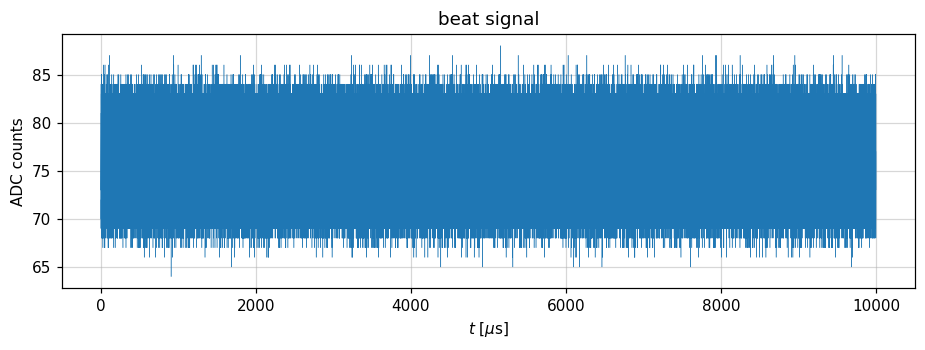

In [17]:
beat = acq.digital_main[0].astype(np.float64)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(acq.t * 1e6, beat, lw=0.3, color='C0')
ax.set_xlabel(r'$t$ [$\mu$s]')
ax.set_ylabel('ADC counts')
ax.set_title(f'beat signal')
ax.grid(alpha=0.5)
plt.show()

## 4. The reflectogram

`fft(beat)` maps each beat frequency to a fibre position (`z = c f / (2 n gamma)`).
The Rayleigh speckle gives a flat random floor that drops to the noise level
right after the fibre end (red dashed line).


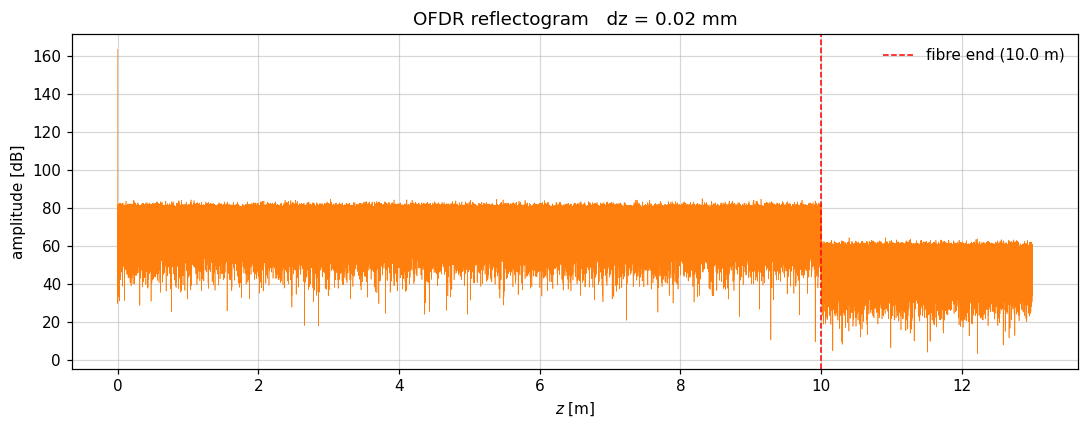

In [18]:
H        = np.fft.fft(beat)
n_half   = len(H) // 2
z        = np.arange(n_half) * acq.dz
amp_dB   = 20 * np.log10(np.abs(H[:n_half]) + 1e-30)

L = cfg['fiber']['length']
mask = z <= 1.3 * L

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z[mask], amp_dB[mask], lw=0.4, color='C1')
ax.axvline(L, color='r', ls='--', lw=1, label=f'fibre end ({L} m)')
ax.set_xlabel(r'$z$ [m]')
ax.set_ylabel('amplitude [dB]')
ax.set_title(f'OFDR reflectogram   dz = {acq.dz*1e3:.2f} mm')
ax.legend(frameon=False, loc='upper right')
ax.grid(alpha=0.5)
fig.tight_layout()
plt.show()

## 5. Multi-sweep & reproducibility

With `n_sweeps > 1` the fibre profile is shared across sweeps but every
noise source (laser phase, RIN, shot, thermal, dark, ADC jitter) gets a
fresh draw. Two consecutive sweeps from the same run differ; two full runs
with the same seed match bit for bit.


In [19]:
cfg_multi = load_config('../configs/ofdr_basic.yaml')
cfg_multi['simulation']['n_sweeps'] = 2

run_a = run_campaign(cfg_multi)
run_b = run_campaign(cfg_multi)        # rerun with the same config

beats_a = [acq.digital_main[0] for acq in run_a]
beats_b = [acq.digital_main[0] for acq in run_b]

print(f"sweep 0 vs sweep 1 (same run): equal = {np.array_equal(beats_a[0], beats_a[1])}")
print(f"sweep 0 across two runs      : equal = {np.array_equal(beats_a[0], beats_b[0])}")
print(f"sweep 1 across two runs      : equal = {np.array_equal(beats_a[1], beats_b[1])}")

sweep 0 vs sweep 1 (same run): equal = False
sweep 0 across two runs      : equal = True
sweep 1 across two runs      : equal = True


## 6. One tweak, one re-run

- `source.power_envelope_edge_dB = 6`: 6 dB droop of the laser power at the sweep edges, parabolic shape
- `detection.balanced = True`: use a balanced photodiode pair instead of single-ended (cancels common-mode RIN and DC)


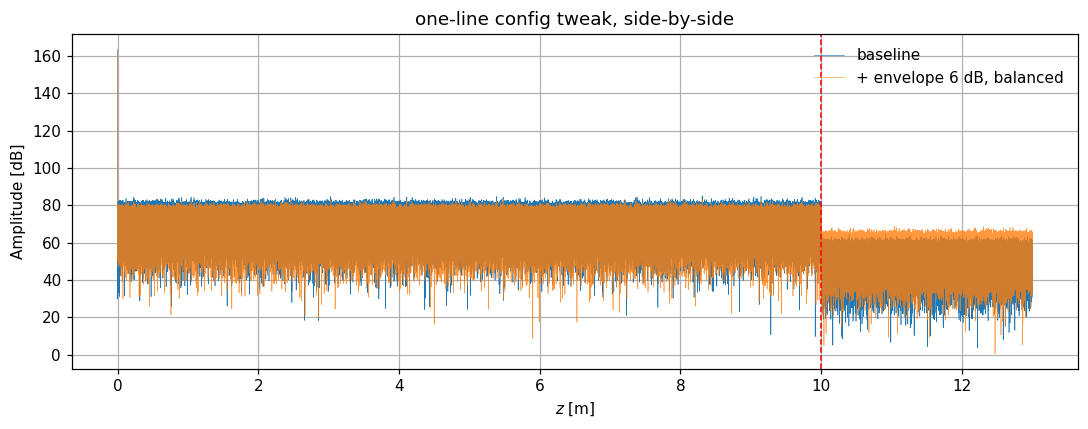

In [21]:
cfg_b = load_config('../configs/ofdr_basic.yaml')
cfg_b['source']['power_envelope_edge_dB'] = 6.0
cfg_b['detection']['balanced']            = True

acq_b   = run_campaign(cfg_b)[-1]
beat_b  = acq_b.digital_main[0].astype(np.float64)
amp_b_dB = 20 * np.log10(np.abs(np.fft.fft(beat_b)[:n_half]) + 1e-30)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z[mask], amp_dB[mask],   lw=0.4, label='baseline')
ax.plot(z[mask], amp_b_dB[mask], lw=0.4, alpha=0.8, label='+ envelope 6 dB, balanced')
ax.axvline(L, color='r', ls='--', lw=1)
ax.set_xlabel(r'$z$ [m]')
ax.set_ylabel('Amplitude [dB]')
ax.set_title('one-line config tweak, side-by-side')
ax.legend(frameon=False, loc='upper right')
ax.grid()
fig.tight_layout()
plt.show()